# Harassment Detection Pipeline
### Bangla | English | Banglish — Multilingual + Sentiment-Aware

**Pipeline Steps:**
1. Install and Import Libraries
2. Load Datasets
3. Explore Raw Data
4. Preprocessing
5. Visualization (one graph per cell)
6. Sentiment Feature Engineering
7. Model Training and Evaluation
8. Manual Comment Testing

---
## 1. Install and Import Libraries

In [1]:
# Install required packages (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost vaderSentiment textblob scipy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import MaxAbsScaler
from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Load Datasets

In [3]:
df_ba = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/Bengali%20hate%20speech_updated.csv")
df_en = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_50000.csv")
df_bl = pd.read_csv("https://raw.githubusercontent.com/NafisOfficial/Social-Media-Full-Project/refs/heads/main/Datasets/toxic_comments_dataset_updated.csv")

df_ba['lang_source'] = 'bangla'
df_en['lang_source'] = 'english'
df_bl['lang_source'] = 'banglish'

print(f'Bangla   dataset: {df_ba.shape[0]:,} rows x {df_ba.shape[1]} cols')
print(f'English  dataset: {df_en.shape[0]:,} rows x {df_en.shape[1]} cols')
print(f'Banglish dataset: {df_bl.shape[0]:,} rows x {df_bl.shape[1]} cols')

Bangla   dataset: 30,000 rows x 8 cols
English  dataset: 49,998 rows x 8 cols
Banglish dataset: 49,998 rows x 8 cols


---
## 3. Explore Raw Data

In [4]:
print('=== BANGLA DATASET ===')
display(df_ba.head(5))
print(f'Columns : {list(df_ba.columns)}')
print(f'Nulls   :\n{df_ba.isnull().sum()}')
print(f"Label distribution:\n{df_ba['hate'].value_counts()}")

=== BANGLA DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,যত্তসব পাপন শালার ফাজলামী!!!!!,1,bangla,yes,bullying,5,0.84,bangla
1,পাপন শালা রে রিমান্ডে নেওয়া দরকার,1,bangla,yes,threat,3,0.98,bangla
2,জিল্লুর রহমান স্যারের ছেলে এতো বড় জারজ হবে এটা...,1,bangla,yes,threat,5,0.93,bangla
3,শালা লুচ্চা দেখতে পাঠার মত দেখা যায়,1,bangla,yes,bullying,5,0.89,bangla
4,তুই তো শালা গাজা খাইছচ।তুর মার হেডায় খেলবে সাকিব,1,bangla,yes,sexual_harassment,3,0.79,bangla


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    20000
1    10000
Name: count, dtype: int64


In [5]:
print('=== ENGLISH DATASET ===')
display(df_en.head(5))
print(f'Columns : {list(df_en.columns)}')
print(f'Nulls   :\n{df_en.isnull().sum()}')
print(f"Label distribution:\n{df_en['hate'].value_counts()}")

=== ENGLISH DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,What nonsense is this,1,online_comment,yes,hate_speech,5,0.84,english
1,What nonsense is this 😂,1,online_comment,yes,hate_speech,3,0.98,english
2,This is so wtupid,1,online_comment,yes,hate_speech,5,0.93,english
3,You are useless,1,online_comment,yes,bullying,5,0.89,english
4,What nonsense is this,1,online_comment,yes,hate_speech,3,0.79,english


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    33332
1    16666
Name: count, dtype: int64


In [6]:
print('=== BANGLISH DATASET ===')
display(df_bl.head(5))
print(f'Columns : {list(df_bl.columns)}')
print(f'Nulls   :\n{df_bl.isnull().sum()}')
print(f"Label distribution:\n{df_bl['hate'].value_counts()}")

=== BANGLISH DATASET ===


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source
0,Tmi ki ba bujho 🤮,1,English,yes,hate_speech,5,0.84,banglish
1,Tmi ki ba bujho,1,English,yes,hate_speech,3,0.98,banglish
2,Tmi ki oa bujho... 😂,1,English,yes,hate_speech,5,0.93,banglish
3,Eta pura nonsense,1,Mixed,yes,hate_speech,5,0.89,banglish
4,Eta pura nonsense 😤,1,English,yes,hate_speech,3,0.79,banglish


Columns : ['sentence', 'hate', 'category', 'is_harassment', 'harassment_type', 'severity', 'confidence_score', 'lang_source']
Nulls   :
sentence            0
hate                0
category            0
is_harassment       0
harassment_type     0
severity            0
confidence_score    0
lang_source         0
dtype: int64
Label distribution:
hate
0    33332
1    16666
Name: count, dtype: int64


---
## 4. Preprocessing

In [7]:
def clean_text(text):
    """
    Clean a single comment:
    - Remove URLs
    - Collapse repeated punctuation (!!!!! -> !)
    - Collapse multiple spaces
    - Preserve Bengali Unicode characters and emojis (both carry sentiment signal)
    """
    text = str(text).strip()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'([!?.])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def preprocess(df, name):
    original = len(df)
    df = df.copy()

    df.columns = df.columns.str.strip().str.lower()
    df.dropna(subset=['sentence', 'hate'], inplace=True)

    df['hate'] = (
        df['hate'].astype(str).str.strip().str.lower()
        .map(lambda x: 1 if x in ['1', 'yes', 'true', 'hate'] else 0)
    )

    df['sentence'] = df['sentence'].apply(clean_text)
    df = df[df['sentence'].str.len() > 1]

    if 'harassment_type' in df.columns:
        df['harassment_type'] = (
            df['harassment_type'].astype(str).str.strip().str.lower()
            .replace('nan', 'unknown')
        )
    else:
        df['harassment_type'] = 'unknown'

    if 'severity' in df.columns:
        df['severity'] = (
            pd.to_numeric(df['severity'], errors='coerce')
            .fillna(0).astype(int).clip(0, 5)
        )
    else:
        df['severity'] = 0

    def sev_label(s):
        if s == 0:     return 'none'
        elif s <= 2:   return 'mild'
        elif s <= 3:   return 'moderate'
        else:          return 'severe'

    df['severity_label'] = df['severity'].apply(sev_label)

    before_dedup = len(df)
    df.drop_duplicates(subset=['sentence'], inplace=True)

    df['text_length'] = df['sentence'].str.len()
    df = df.reset_index(drop=True)

    print(f'[{name}]')
    print(f'  Original rows   : {original:,}')
    print(f'  After cleaning  : {len(df):,}')
    print(f'  Duplicates drop : {before_dedup - len(df):,}')
    print(f'  Harassment  (1) : {df["hate"].sum():,}')
    print(f'  Normal      (0) : {(df["hate"]==0).sum():,}')
    print()
    return df


print('Preprocessing...')
df_ba = preprocess(df_ba, 'Bangla')
df_en = preprocess(df_en, 'English')
df_bl = preprocess(df_bl, 'Banglish')

df = pd.concat([df_ba, df_en, df_bl], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Merged Dataset')
print(f'  Total rows      : {len(df):,}')
print(f'  Harassment  (1) : {df["hate"].sum():,}')
print(f'  Normal      (0) : {(df["hate"]==0).sum():,}')
display(df.head(5))

Preprocessing...


[Bangla]
  Original rows   : 30,000
  After cleaning  : 29,828
  Duplicates drop : 156
  Harassment  (1) : 9,958
  Normal      (0) : 19,870

[English]
  Original rows   : 49,998
  After cleaning  : 13,584
  Duplicates drop : 36,414
  Harassment  (1) : 4,522
  Normal      (0) : 9,062

[Banglish]
  Original rows   : 49,998
  After cleaning  : 13,771
  Duplicates drop : 36,227
  Harassment  (1) : 4,553
  Normal      (0) : 9,218

Merged Dataset
  Total rows      : 57,183
  Harassment  (1) : 19,033
  Normal      (0) : 38,150


,sentence,hate,category,is_harassment,harassment_type,severity,confidence_score,lang_source,severity_label,text_length
0,I will report you? 🤮,0,online_comment,no,none,1,0.93,english,mild,20
1,পরকীয়া পেম করলে ভাল ভাল ছেলেদের এমন হয় আমি মনে...,0,bangla,no,none,2,0.76,bangla,mild,68
2,চোরের কমিটি।,0,bangla,no,none,2,0.83,bangla,mild,12
3,অভিনয়কাকেবলেজসিমস্যারজানে,0,bangla,no,none,2,0.94,bangla,mild,25
4,যখন মারছিলো তখন মনে পড়ে নাই ঠিকই আছে বিচার এদে...,0,bangla,no,none,2,0.85,bangla,mild,66


---
## 5. Visualization
Each graph is shown in its own separate cell.

In [8]:
# Color palette
C_GREEN  = '#2ECC71'
C_RED    = '#E74C3C'
C_BLUE   = '#3498DB'
C_ORANGE = '#E67E22'
C_YELLOW = '#F1C40F'
C_PURPLE = '#9B59B6'

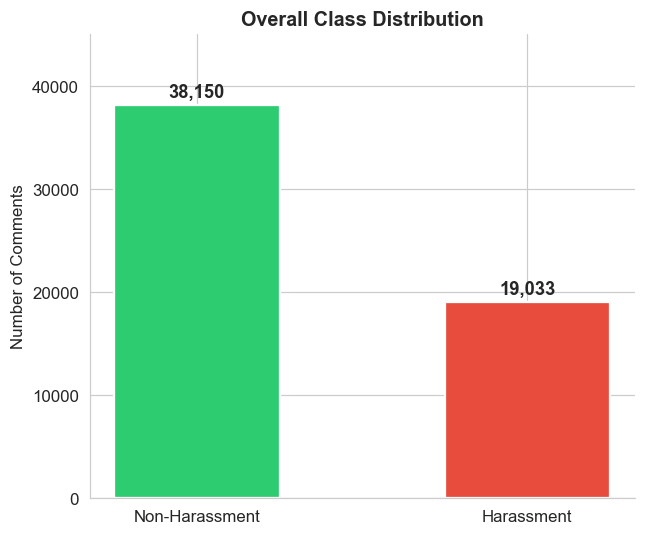

In [9]:
# Graph 1: Overall Class Distribution
fig, ax = plt.subplots(figsize=(6, 5))

labels = ['Non-Harassment', 'Harassment']
counts = [(df['hate'] == 0).sum(), df['hate'].sum()]
bars = ax.bar(labels, counts, color=[C_GREEN, C_RED], edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts) * 0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Overall Class Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Number of Comments')
ax.set_ylim(0, max(counts) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_01_class_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

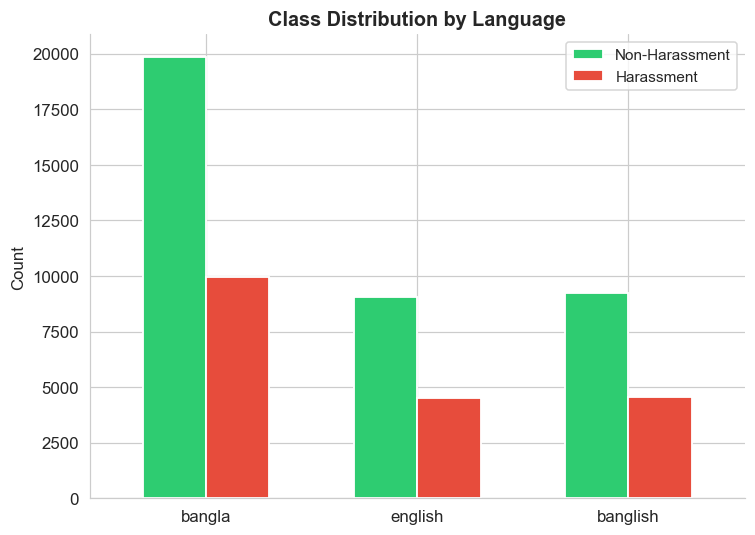

In [10]:
# Graph 2: Class Distribution by Language
fig, ax = plt.subplots(figsize=(7, 5))

lang_grp = df.groupby(['lang_source', 'hate']).size().unstack(fill_value=0)
lang_grp.columns = ['Non-Harassment', 'Harassment']
lang_grp = lang_grp.reindex(['bangla', 'english', 'banglish'])
lang_grp.plot(kind='bar', ax=ax, color=[C_GREEN, C_RED], edgecolor='white', linewidth=1.2, width=0.6)

ax.set_title('Class Distribution by Language', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_02_class_by_language.png', bbox_inches='tight', dpi=120)
plt.show()

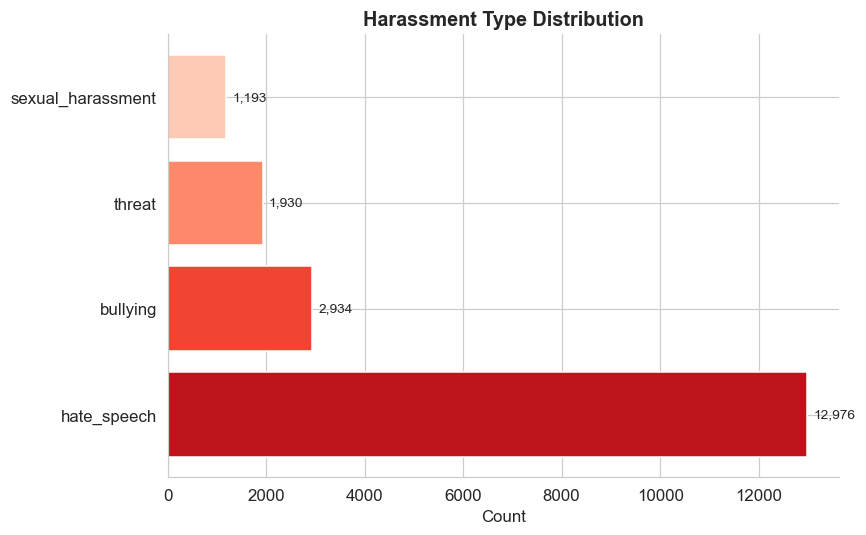

In [11]:
# Graph 3: Harassment Type Distribution
fig, ax = plt.subplots(figsize=(8, 5))

type_counts = (
    df[df['hate'] == 1]['harassment_type']
    .value_counts()
    .drop(labels=['unknown', 'nan', 'none'], errors='ignore')
    .head(8)
)

pal = sns.color_palette('Reds_r', len(type_counts))
bars = ax.barh(type_counts.index, type_counts.values, color=pal, edgecolor='white', linewidth=1)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_width() + max(type_counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)

ax.set_title('Harassment Type Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Count')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_03_harassment_types.png', bbox_inches='tight', dpi=120)
plt.show()

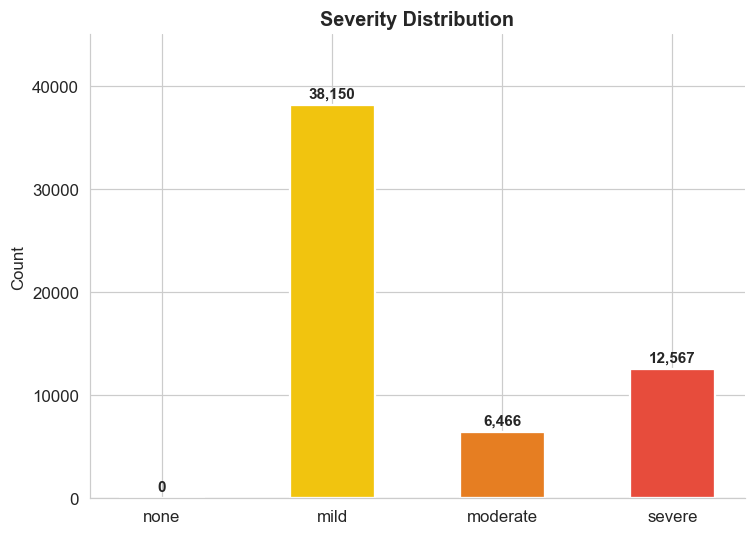

In [12]:
# Graph 4: Severity Distribution
fig, ax = plt.subplots(figsize=(7, 5))

sev_order  = ['none', 'mild', 'moderate', 'severe']
sev_colors = [C_GREEN, C_YELLOW, C_ORANGE, C_RED]
sev_counts = df['severity_label'].value_counts().reindex(sev_order, fill_value=0)

bars = ax.bar(sev_counts.index, sev_counts.values,
              color=sev_colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, sev_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(sev_counts.values) * 0.01,
            f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_title('Severity Distribution', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(sev_counts.values) * 1.18)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_04_severity_distribution.png', bbox_inches='tight', dpi=120)
plt.show()

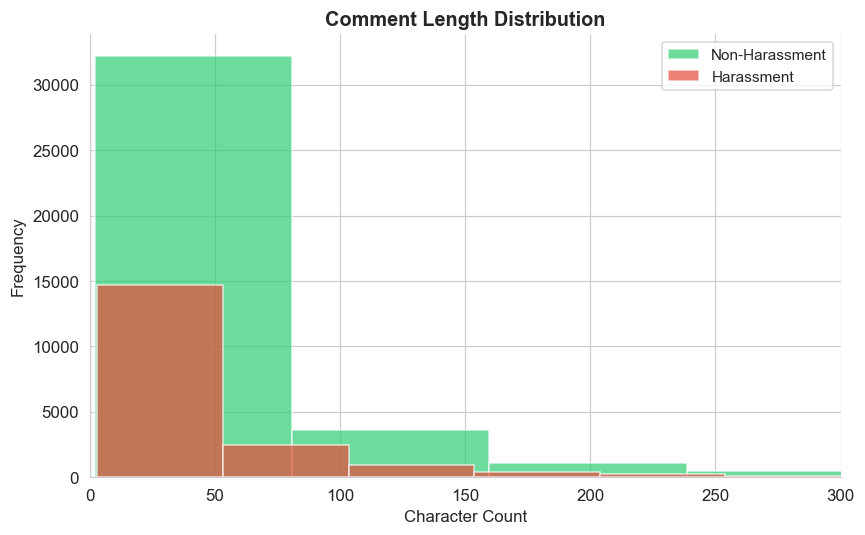

In [13]:
# Graph 5: Comment Length Distribution by Class
fig, ax = plt.subplots(figsize=(8, 5))

df[df['hate'] == 0]['text_length'].hist(
    ax=ax, bins=40, alpha=0.7, color=C_GREEN, label='Non-Harassment', edgecolor='white')
df[df['hate'] == 1]['text_length'].hist(
    ax=ax, bins=40, alpha=0.7, color=C_RED, label='Harassment', edgecolor='white')

ax.set_title('Comment Length Distribution', fontweight='bold', fontsize=13)
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_05_comment_length.png', bbox_inches='tight', dpi=120)
plt.show()

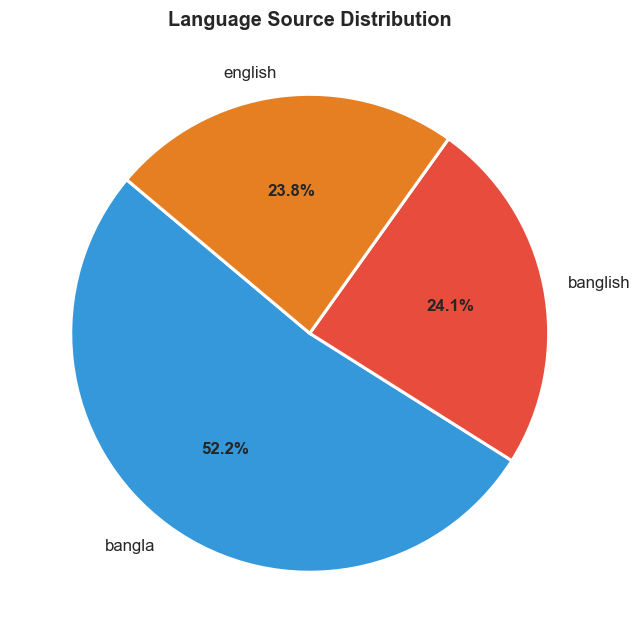

In [14]:
# Graph 6: Language Source Pie Chart
fig, ax = plt.subplots(figsize=(6, 6))

lang_counts = df['lang_source'].value_counts()
pie_colors  = [C_BLUE, C_RED, C_ORANGE]
wedges, texts, autotexts = ax.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')

ax.set_title('Language Source Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('graph_06_language_pie.png', bbox_inches='tight', dpi=120)
plt.show()

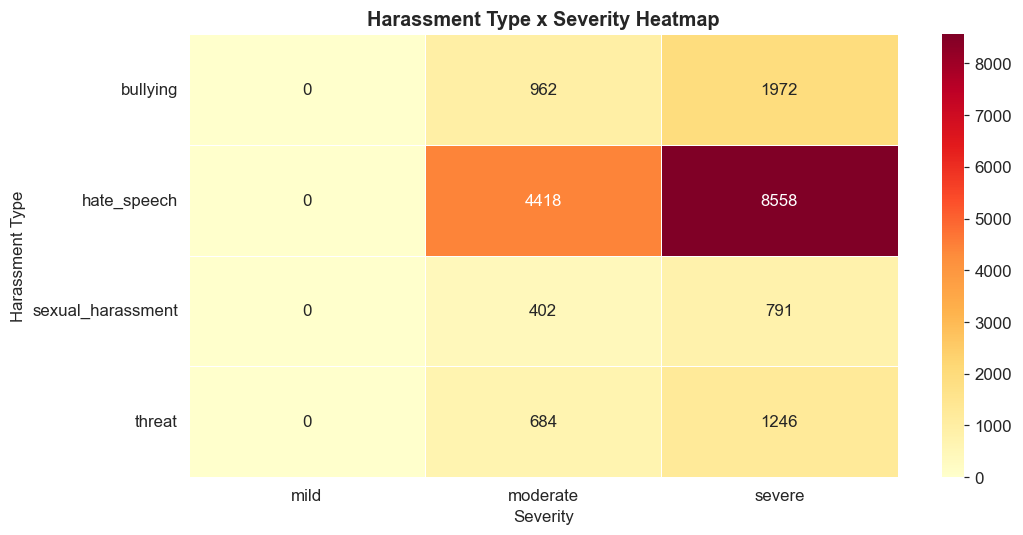

In [15]:
# Graph 7: Harassment Type x Severity Heatmap
fig, ax = plt.subplots(figsize=(10, 5))

pivot = (
    df[df['hate'] == 1]
    .groupby(['harassment_type', 'severity_label'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['mild', 'moderate', 'severe'], fill_value=0)
)
pivot = pivot[~pivot.index.isin(['unknown', 'nan', 'none'])]

sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax)

ax.set_title('Harassment Type x Severity Heatmap', fontweight='bold', fontsize=13)
ax.set_xlabel('Severity')
ax.set_ylabel('Harassment Type')
plt.tight_layout()
plt.savefig('graph_07_heatmap_type_severity.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 6. Sentiment Feature Engineering

We extract sentiment scores from each comment using VADER (works well for English/Banglish)
and TextBlob polarity/subjectivity. These numeric features are stacked alongside TF-IDF
vectors so the model understands emotional tone, not just vocabulary.

In [16]:
vader = SentimentIntensityAnalyzer()


def get_sentiment_features(texts):
    """
    Returns a (n_samples, 6) numpy array of sentiment features:
      [vader_neg, vader_neu, vader_pos, vader_compound,
       textblob_polarity, textblob_subjectivity]

    These features help the model detect:
      - Negative tone (anger, hostility) via vader_neg and vader_compound
      - Strong emotional subjectivity (personal attacks) via textblob_subjectivity
      - Works for English and Banglish; Bangla is handled lexically via TF-IDF
    """
    rows = []
    for text in texts:
        vs = vader.polarity_scores(text)
        tb = TextBlob(text)
        rows.append([
            vs['neg'],
            vs['neu'],
            vs['pos'],
            vs['compound'],
            tb.sentiment.polarity,
            tb.sentiment.subjectivity,
        ])
    return np.array(rows, dtype=np.float32)


print('Computing sentiment features for all comments...')
sent_features = get_sentiment_features(df['sentence'].tolist())
print(f'Sentiment feature matrix shape: {sent_features.shape}')

df['vader_compound']         = sent_features[:, 3]
df['textblob_polarity']      = sent_features[:, 4]
df['textblob_subjectivity']  = sent_features[:, 5]
print('Sentiment features added to dataframe.')

Computing sentiment features for all comments...
Sentiment feature matrix shape: (57183, 6)
Sentiment features added to dataframe.


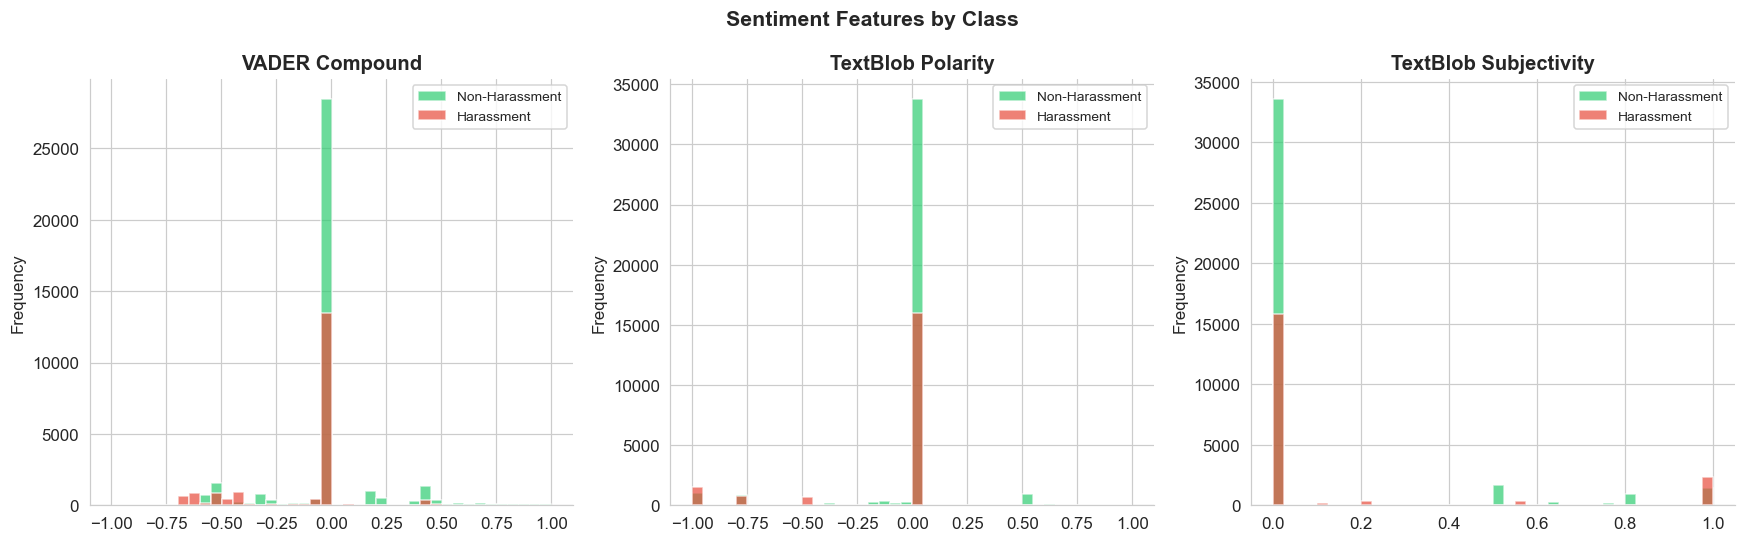

In [17]:
# Graph 8: Sentiment Score Distribution by Class
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Features by Class', fontweight='bold', fontsize=14)

for ax, col, title in zip(
    axes,
    ['vader_compound', 'textblob_polarity', 'textblob_subjectivity'],
    ['VADER Compound', 'TextBlob Polarity', 'TextBlob Subjectivity']
):
    df[df['hate'] == 0][col].hist(ax=ax, bins=40, alpha=0.7, color=C_GREEN,
                                  label='Non-Harassment', edgecolor='white')
    df[df['hate'] == 1][col].hist(ax=ax, bins=40, alpha=0.7, color=C_RED,
                                  label='Harassment', edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graph_08_sentiment_by_class.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 7. Model Training and Evaluation

### Why this model is special for Bangla / English / Banglish:
- **Dual TF-IDF**: character n-grams (handles Bangla script, Banglish typos) + word n-grams (English semantics)
- **Sentiment features**: VADER and TextBlob scores fused into the feature matrix
- **XGBoost**: gradient-boosted trees that handle mixed numeric + sparse features natively
- **class_weight balanced**: compensates for label imbalance across all three datasets

In [18]:
X_raw  = df['sentence'].values
y      = df['hate'].values
S_all  = csr_matrix(sent_features)

# Character-level TF-IDF: captures Bengali script and Banglish subword patterns
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(2, 4),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,
    strip_accents=None
)

# Word-level TF-IDF: captures English word semantics
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=30000,
    sublinear_tf=True,
    min_df=2
)

print('Fitting TF-IDF vectorizers...')
X_char = tfidf_char.fit_transform(X_raw)
X_word = tfidf_word.fit_transform(X_raw)

# Stack character + word + sentiment features into a single matrix
X_full = hstack([X_char, X_word, S_all])
print(f'Full feature matrix shape: {X_full.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]:,} samples  |  Harassment: {y_train.sum():,} ({y_train.mean():.1%})')
print(f'Test : {X_test.shape[0]:,} samples   |  Harassment: {y_test.sum():,} ({y_test.mean():.1%})')

Fitting TF-IDF vectorizers...
Full feature matrix shape: (57183, 80006)
Train: 45,746 samples  |  Harassment: 15,226 (33.3%)
Test : 11,437 samples   |  Harassment: 3,807 (33.3%)


In [19]:
# Compute class weight ratio for XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Class weight ratio (neg/pos): {scale_pos_weight:.2f}')

models = {
    'Logistic Regression': LogisticRegression(
        C=5, max_iter=1000, class_weight='balanced', solver='lbfgs'
    ),
    'Linear SVM': LinearSVC(
        C=1.0, max_iter=3000, class_weight='balanced', dual=True
    ),
    'XGBoost (Multilingual + Sentiment)': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric='logloss',
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    ),
}

results = {}
trained = {}

for name, clf in models.items():
    print(f'\nTraining {name}...')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')
    f1h = f1_score(y_test, y_pred, pos_label=1)

    results[name] = {'Accuracy': acc, 'F1 Macro': f1, 'F1 Harassment': f1h}
    trained[name] = (clf, y_pred)

    print(f'  Accuracy      : {acc:.4f}')
    print(f'  F1 (macro)    : {f1:.4f}')
    print(f'  F1 Harassment : {f1h:.4f}')

print('\nAll models trained.')

Class weight ratio (neg/pos): 2.00

Training Logistic Regression...
  Accuracy      : 0.9440
  F1 (macro)    : 0.9369
  F1 Harassment : 0.9157

Training Linear SVM...
  Accuracy      : 0.9405
  F1 (macro)    : 0.9327
  F1 Harassment : 0.9100

Training XGBoost (Multilingual + Sentiment)...


KeyboardInterrupt: 

In [ ]:
best_name = max(results, key=lambda k: results[k]['F1 Macro'])
best_clf, best_pred = trained[best_name]

print(f'Best model : {best_name}')
print('\nClassification Report')
print(classification_report(y_test, best_pred,
      target_names=['Non-Harassment', 'Harassment']))

Best model : XGBoost (Multilingual + Sentiment)

Classification Report
                precision    recall  f1-score   support

Non-Harassment       0.96      0.96      0.96      7630
    Harassment       0.92      0.92      0.92      3807

      accuracy                           0.95     11437
     macro avg       0.94      0.94      0.94     11437
  weighted avg       0.95      0.95      0.95     11437



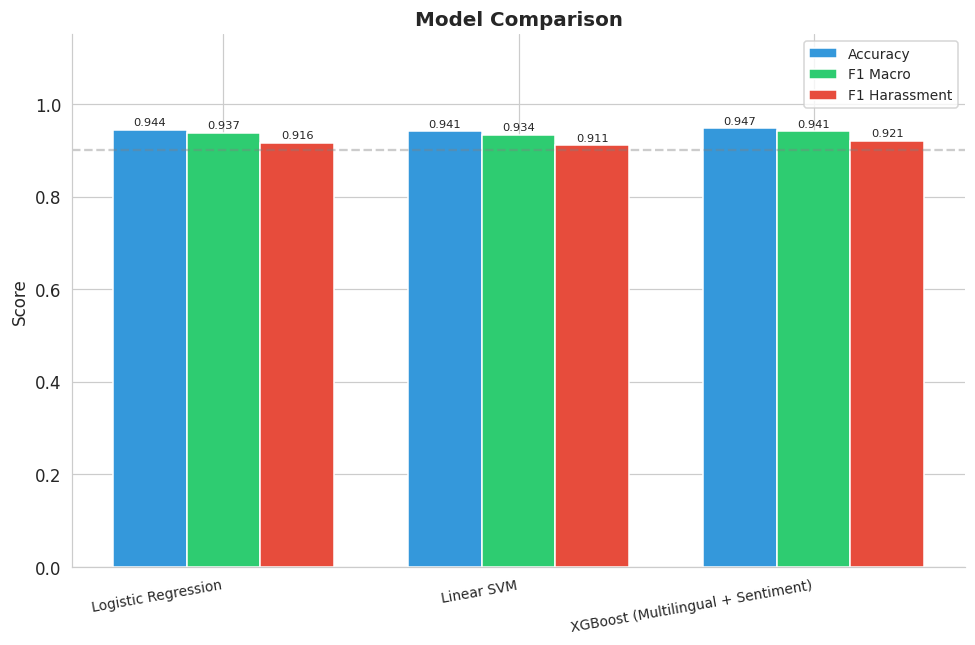

In [ ]:
# Graph 9: Model Comparison
fig, ax = plt.subplots(figsize=(9, 6))

model_names = list(results.keys())
accs = [results[m]['Accuracy']      for m in model_names]
f1s  = [results[m]['F1 Macro']      for m in model_names]
f1hs = [results[m]['F1 Harassment'] for m in model_names]
x    = np.arange(len(model_names))
w    = 0.25

b1 = ax.bar(x - w,  accs, w, label='Accuracy',      color=C_BLUE,  edgecolor='white')
b2 = ax.bar(x,      f1s,  w, label='F1 Macro',      color=C_GREEN, edgecolor='white')
b3 = ax.bar(x + w,  f1hs, w, label='F1 Harassment', color=C_RED,   edgecolor='white')

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Model Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_09_model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

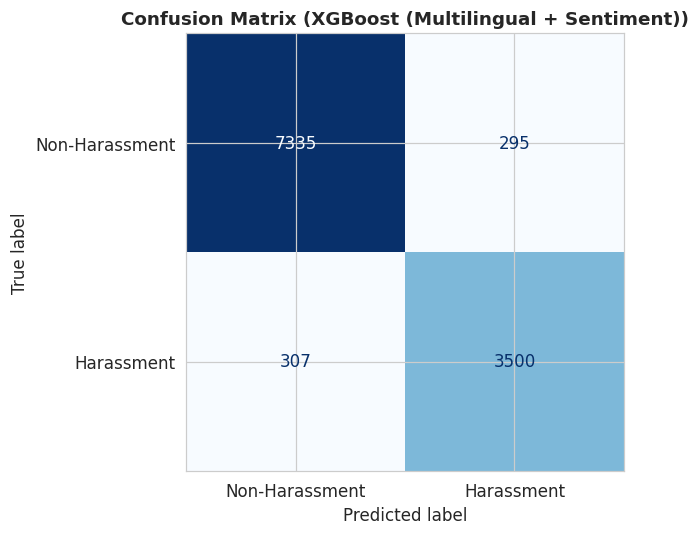

In [ ]:
# Graph 10: Confusion Matrix (best model)
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, best_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Harassment', 'Harassment']
).plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Confusion Matrix ({best_name})', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('graph_10_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

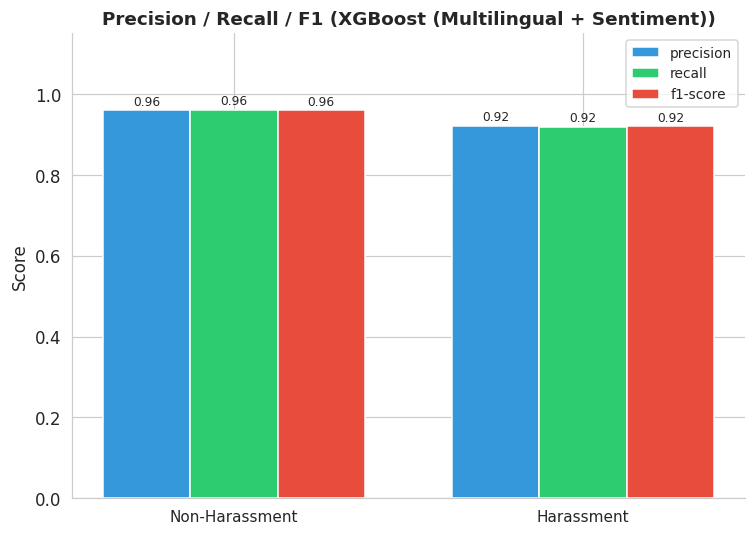

In [ ]:
# Graph 11: Per-class Precision / Recall / F1
fig, ax = plt.subplots(figsize=(7, 5))

report   = classification_report(
    y_test, best_pred,
    target_names=['Non-Harassment', 'Harassment'],
    output_dict=True
)
classes  = ['Non-Harassment', 'Harassment']
metrics  = ['precision', 'recall', 'f1-score']
m_colors = [C_BLUE, C_GREEN, C_RED]
x2 = np.arange(len(classes))

for i, (metric, color) in enumerate(zip(metrics, m_colors)):
    vals = [report[c][metric] for c in classes]
    bars = ax.bar(x2 + (i - 1) * 0.25, vals, 0.25,
                  label=metric, color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x2)
ax.set_xticklabels(classes, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title(f'Precision / Recall / F1 ({best_name})', fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('graph_11_precision_recall_f1.png', bbox_inches='tight', dpi=120)
plt.show()

---
## 8. Manual Comment Testing

In [ ]:
def get_action(severity, confidence):
    """Map severity and confidence to a moderation action."""
    if severity >= 4 and confidence >= 0.85:
        return {'action': 'AUTO-HIDE',       'notify': True,  'priority': 'HIGH'}
    elif severity >= 3 and confidence >= 0.70:
        return {'action': 'AUTO-HIDE',       'notify': True,  'priority': 'MEDIUM'}
    elif severity >= 1 and confidence >= 0.55:
        return {'action': 'FLAG FOR REVIEW', 'notify': True,  'priority': 'LOW'}
    else:
        return {'action': 'ALLOW',           'notify': False, 'priority': 'SAFE'}


def predict(text, clf, tfidf_char, tfidf_word):
    """
    Run full prediction for a single comment.
    Builds the same char + word + sentiment feature vector used during training.
    """
    text  = clean_text(text)

    x_c   = tfidf_char.transform([text])
    x_w   = tfidf_word.transform([text])
    s_vec = csr_matrix(get_sentiment_features([text]))
    x_in  = hstack([x_c, x_w, s_vec])

    label = clf.predict(x_in)[0]

    try:
        proba      = clf.predict_proba(x_in)[0]
        confidence = float(proba[label])
    except AttributeError:
        score      = clf.decision_function(x_in)[0]
        confidence = float(1 / (1 + np.exp(-abs(score))))

    # Sentiment details for display
    vs = vader.polarity_scores(text)
    tb = TextBlob(text)

    if label == 0:
        severity       = 0
        severity_label = 'none'
    else:
        if   confidence >= 0.92: severity = 5; severity_label = 'severe'
        elif confidence >= 0.82: severity = 4; severity_label = 'severe'
        elif confidence >= 0.72: severity = 3; severity_label = 'moderate'
        elif confidence >= 0.60: severity = 2; severity_label = 'mild'
        else:                    severity = 1; severity_label = 'mild'

    action = get_action(severity, confidence)

    return {
        'text':                  text,
        'is_harassment':         bool(label),
        'confidence':            round(confidence, 4),
        'severity':              severity,
        'severity_label':        severity_label,
        'action':                action['action'],
        'notify_admin':          action['notify'],
        'priority':              action['priority'],
        'vader_negative':        round(vs['neg'], 3),
        'vader_compound':        round(vs['compound'], 3),
        'textblob_polarity':     round(tb.sentiment.polarity, 3),
        'textblob_subjectivity': round(tb.sentiment.subjectivity, 3),
    }


def show_result(result):
    """Print a prediction result in a readable table."""
    sep = '-' * 60
    print(sep)
    preview = result['text'][:80] + ('...' if len(result['text']) > 80 else '')
    print(f"  Comment           : {preview}")
    print(f"  Harassment        : {'YES' if result['is_harassment'] else 'NO'}")
    print(f"  Confidence        : {result['confidence']:.2%}")
    print(f"  Severity          : {result['severity_label'].upper()} ({result['severity']}/5)")
    print(f"  Action            : {result['action']}")
    print(f"  Notify Admin      : {'YES' if result['notify_admin'] else 'No'}")
    print(f"  Priority          : {result['priority']}")
    print(f"  VADER Compound    : {result['vader_compound']}")
    print(f"  TextBlob Polarity : {result['textblob_polarity']}")
    print(f"  Subjectivity      : {result['textblob_subjectivity']}")
    print(sep)


print('Prediction functions ready.')

Prediction functions ready.


In [ ]:
# Sample predictions across all three languages
sample_comments = [
    # Non-harassment
    'আজকে আবহাওয়া অনেক সুন্দর ছিল, বাইরে গিয়েছিলাম।',
    'Great match today! Bangladesh played really well.',
    'Vai tomar post ta onek sundor hoiche!',

    # Harassment
    'তোকে দেখে নেব, সাবধান থাকিস।',
    'You are completely useless, nobody likes you, just disappear.',
    'Tui ekta pagol, tore keo patta dey na shobai hate kore toke.',
    'তোমাদের ধর্মের মানুষরা সবাই সমাজের জন্য ক্ষতিকর।',
]

print('=== Sample Predictions ===\n')
for comment in sample_comments:
    result = predict(comment, best_clf, tfidf_char, tfidf_word)
    show_result(result)

=== Sample Predictions ===

------------------------------------------------------------
  Comment           : আজকে আবহাওয়া অনেক সুন্দর ছিল, বাইরে গিয়েছিলাম।
  Harassment        : NO
  Confidence        : 94.06%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Notify Admin      : No
  Priority          : SAFE
  VADER Compound    : 0.0
  TextBlob Polarity : 0.0
  Subjectivity      : 0.0
------------------------------------------------------------
------------------------------------------------------------
  Comment           : Great match today! Bangladesh played really well.
  Harassment        : NO
  Confidence        : 97.90%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Notify Admin      : No
  Priority          : SAFE
  VADER Compound    : 0.848
  TextBlob Polarity : 0.6
  Subjectivity      : 0.475
------------------------------------------------------------
------------------------------------------------------------
  Comment           : Vai toma

In [ ]:
# Test your own comment here
# Replace the string below with any Bangla, English, or Banglish comment.

my_comment = "তোকে মেরে ফেলব"

result = predict(my_comment, best_clf, tfidf_char, tfidf_word)
show_result(result)

------------------------------------------------------------
  Comment           : তোকে মেরে ফেলব
  Harassment        : NO
  Confidence        : 72.21%
  Severity          : NONE (0/5)
  Action            : ALLOW
  Notify Admin      : No
  Priority          : SAFE
  VADER Compound    : 0.0
  TextBlob Polarity : 0.0
  Subjectivity      : 0.0
------------------------------------------------------------
